In [29]:
print("Project 6: Outfit Recommender V4 - Edge and Texture Features")

Project 6: Outfit Recommender V4 - Edge and Texture Features


In [30]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from PIL import Image
from sklearn.cluster import KMeans
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler

In [31]:
def get_features(image_path, n_colors=3):
    img = Image.open(image_path).convert("RGB")
    img = img.resize((100, 100))

    img_array = np.array(img)
    flat_pixels = img_array.reshape(-1, 3)

    # Dominant colors
    kmeans = KMeans(n_clusters=n_colors, random_state=42)
    kmeans.fit(flat_pixels)
    colors = kmeans.cluster_centers_

    # Brightness
    brightness = np.mean(flat_pixels)

    # Contrast
    contrast = np.std(flat_pixels)

    # Convert to grayscale for edge/texture features
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY)

    # Edge density: how many edges exist in the image
    edges = cv2.Canny(gray, threshold1=100, threshold2=200)
    edge_density = np.sum(edges > 0) / edges.size

    # Texture: how much grayscale intensity varies
    texture = np.std(gray)

    # Final V4 feature vector
    feature_vector = np.concatenate([
        colors.flatten(),
        [brightness, contrast, edge_density, texture]
    ])

    return feature_vector

In [32]:
IMAGE_FOLDER = "../images"

files = [
    f for f in os.listdir(IMAGE_FOLDER)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
]

print("Number of images:", len(files))
print(files[:5])

Number of images: 26
['#outfits #fashion #summer #summerstyle.jpg', '30 Effortlessly Chic Outfits to Copy for Summer.jpg', '5 Summer Outfits To Wear In The Hamptons - The Girl from Panama.jpg', 'Another Day in Denim.jpg', 'download (1).jpg']


In [33]:
all_features = []

for file in files:
    path = os.path.join(IMAGE_FOLDER, file)
    features = get_features(path)
    all_features.append(features)

all_features = np.array(all_features)

print("Raw feature shape:", all_features.shape)
print("Example raw feature:", all_features[0])

Raw feature shape: (26, 13)
Example raw feature: [1.82524665e+02 1.82570279e+02 1.78590506e+02 1.20157386e+02
 1.16756252e+02 1.13993998e+02 3.66864564e+01 3.25324675e+01
 3.00264378e+01 1.30016700e+02 6.19589737e+01 1.48200000e-01
 6.17261985e+01]


In [34]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(all_features)

print("Scaled feature shape:", scaled_features.shape)

Scaled feature shape: (26, 13)


In [35]:
style_model = KMeans(n_clusters=3, random_state=42)
style_labels = style_model.fit_predict(scaled_features)

C:\Users\ousama\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [36]:
style_names = {
    0: "Style Group 0",
    1: "Style Group 1",
    2: "Style Group 2"
}


In [37]:
def recommend_similar_outfits(image_path, top_n=3):
    new_feature = get_features(image_path)
    new_feature_scaled = scaler.transform([new_feature])

    similarities = cosine_similarity(new_feature_scaled, scaled_features)[0]

    input_filename = os.path.basename(image_path)

    if input_filename in files:
        input_index = files.index(input_filename)
        input_style = style_labels[input_index]
    else:
        input_style = style_model.predict(new_feature_scaled)[0]

    print("Input style:", style_names[input_style])

    sorted_indexes = similarities.argsort()[::-1]

    shown = 0

    for index in sorted_indexes:
        file = files[index]

        if file == input_filename:
            continue

        if style_labels[index] != input_style:
            continue

        score = similarities[index]

        img_path = os.path.join(IMAGE_FOLDER, file)
        img = Image.open(img_path).convert("RGB")

        print(f"{file} → similarity: {score:.3f}")

        plt.imshow(img)
        plt.title(f"{style_names[input_style]}\n{file}\nSimilarity: {score:.3f}")
        plt.axis("off")
        plt.show()

        shown += 1

        if shown >= top_n:
            break

Input style: Style Group 1
download (5).jpg → similarity: 0.937


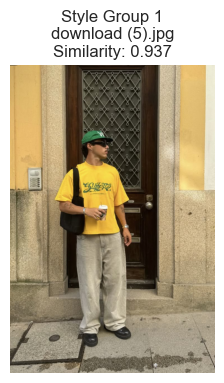

LAURA JADE NUDE HIGH WAISTED MIDI SKIRT WITH BUTTON SIDE SPLIT.jpg → similarity: 0.928


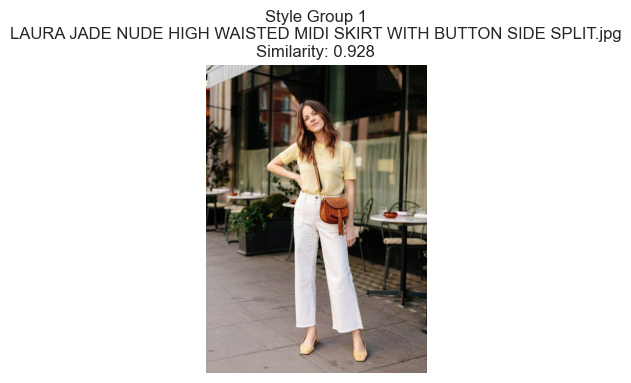

Rose.jpg → similarity: 0.777


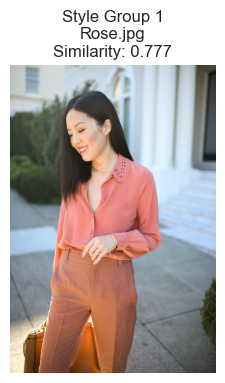

In [38]:
test_image = os.path.join(IMAGE_FOLDER, files[0])
recommend_similar_outfits(test_image, top_n=3)